Exploratory Data Analysis — The Rolling Stones


Sobre o projeto

Este projeto apresenta uma Análise Exploratória de Dados (EDA) sobre músicas e álbuns dos The Rolling Stones, utilizando Python para investigar características musicais, distribuição dos dados, popularidade e diferenças entre gravações.

A análise busca transformar os dados da discografia em informações que permitam compreender melhor o comportamento das músicas ao longo do tempo, explorando características como energia, dançabilidade, acústica, instrumentalidade, vivacidade, valência, tempo, duração e popularidade.

Além da exploração descritiva, o projeto utiliza análises estatísticas e testes de hipóteses para investigar relações e diferenças observadas nos dados.


Objetivos

Compreender a estrutura e qualidade da base de dados;
Identificar e tratar problemas de qualidade, como valores ausentes e registros duplicados;
Explorar as principais características musicais;
Analisar a evolução das músicas ao longo do tempo;
Investigar relações entre características musicais;
Comparar diferentes tipos de gravação quando aplicável;
Utilizar estatística para validar hipóteses levantadas durante a análise;
Comunicar os resultados por meio de visualizações.


Base de dados

A base contém 1.610 registros e 15 variáveis, abrangendo lançamentos entre 1964 e 2022.

Entre as principais variáveis estão:

Variável	Descrição
name	Nome da música
album	Álbum
release_date	Data de lançamento
track_number	Número da faixa
acousticness	Característica acústica da música
danceability	Grau de dançabilidade
energy	Intensidade/energia
instrumentalness	Predominância instrumental
liveness	Indicação de performance ao vivo
loudness	Intensidade sonora
speechiness	Presença de elementos de fala
tempo	Andamento da música
valence	Medida associada ao caráter positivo da música
popularity	Indicador de popularidade
duration_ms	Duração da faixa em milissegundos


Tecnologias utilizadas

Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy e Jupyter Notebook


Etapas da análise

O projeto está organizado nas seguintes etapas:

Importação e inspeção da base;
Análise da estrutura dos dados;
Verificação de valores ausentes;
Identificação de registros duplicados;
Tratamento e criação de novas variáveis;
Análise estatística descritiva;
Visualização das distribuições;
Análise de correlação;
Formulação de hipóteses;
Aplicação de testes estatísticos;
Interpretação dos resultados;
Consolidação dos principais insights.


Principais perguntas analisadas

Ao longo da EDA, a análise busca responder perguntas como:

Como estão distribuídas as principais características musicais?
Como as características das músicas se relacionam entre si?
Existe relação entre características musicais e popularidade?
Como as músicas se distribuem ao longo dos anos?
Existem diferenças estatisticamente relevantes entre diferentes tipos de gravação?
Quais características apresentam maior associação entre si?


Resultado esperado

Mais do que apenas apresentar gráficos, o objetivo é demonstrar um processo completo de Análise Exploratória de Dados, partindo da compreensão e preparação da base até a utilização de métodos estatísticos para apoiar a interpretação dos resultados.

In [62]:
import pandas as pd

In [63]:
df = pd.read_excel("dataset_rolling_stones.xlsx")
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   str           
 1   album             1610 non-null   str           
 2   release_date      1610 non-null   datetime64[us]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 non-null   i

In [65]:
df.shape

(1610, 15)

In [66]:
df.isnull().sum() 

name                0
album               0
release_date        0
track_number        0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [67]:
df.duplicated().sum() 

np.int64(6)

### Insight — Qualidade e estrutura da base

A base possui **1.610 registros e 15 variáveis**, abrangendo lançamentos dos Rolling Stones entre **1964 e 2022**.

Na etapa de validação, não foram identificados valores ausentes. Entretanto, foram encontrados **6 registros duplicados**, indicando a necessidade de uma etapa de tratamento antes da realização das análises estatísticas e visualizações.

Após essa verificação, a base apresenta uma estrutura adequada para a exploração das características musicais e temporais das faixas.


In [68]:
df[df.duplicated()] 

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
928,Some Girls - Remastered,Some Girls (Deluxe Version),1978-06-09,4,0.5270,0.474,0.938,0.520000,0.299,-2643.0,0.0898,71995.00,0.505,21,276933
929,Lies - Remastered,Some Girls (Deluxe Version),1978-06-09,5,0.4370,0.382,0.997,0.950000,0.617,-1568.0,0.1880,162428.00,0.563,16,191266
935,Claudine,Some Girls (Deluxe Version),1978-06-09,1,0.0144,0.439,0.977,0.022100,0.383,-4386.0,0.1280,105124.00,0.364,17,222253
939,No Spare Parts,Some Girls (Deluxe Version),1978-06-09,5,0.2400,0.594,0.762,0.000015,0.712,-5145.0,0.0292,72648.00,0.540,19,270466
940,Don't Be A Stranger,Some Girls (Deluxe Version),1978-06-09,6,0.0610,0.720,0.867,0.029700,0.385,-5871.0,0.0390,127329.00,0.847,15,246266
946,Petrol Blues,Some Girls (Deluxe Version),1978-06-09,12,0.7690,0.835,0.621,0.114000,0.116,-8007.0,0.0406,115.87,0.336,13,95626


In [69]:
print("Data Inicial: ", df["release_date"].min())

Data Inicial:  1964-04-16 00:00:00


In [70]:
print("Data Final: ", df["release_date"].max())

Data Final:  2022-06-10 00:00:00


In [71]:
df.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920


### Insight — Características gerais das músicas

A análise descritiva mostra que as músicas apresentam, em média, **energia de 0,79**, **dançabilidade de 0,47** e **valência de 0,58**.

A duração média das faixas é de aproximadamente **4,30 minutos**, enquanto a mediana é de aproximadamente **4,05 minutos**, indicando uma distribuição com alguma concentração em torno dessa faixa de duração.

Também é possível observar uma ampla variação entre as músicas nas características analisadas, especialmente em duração, instrumentalidade e vivacidade, indicando diferentes perfis musicais dentro da discografia analisada.


In [72]:
df["duracao_em_min"] = df["duration_ms"] / 60000
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100


In [73]:
df.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199,4.295608
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000,0.350000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000,3.176883
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000,4.051550
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000,4.921996
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000,16.364433
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920,1.805558


In [74]:
df.groupby("album")["duracao_em_min"].mean()

album
12 X 5                              2.682068
12 x 5                              2.682772
A Bigger Bang (2009 Re-Mastered)    4.016356
A Bigger Bang (Live)                5.176630
Aftermath                           3.899185
                                      ...   
Undercover                          4.492750
Undercover (2009 Re-Mastered)       4.497595
Voodoo Lounge (Remastered 2009)     4.118779
Voodoo Lounge Uncut (Live)          5.248507
got LIVE if you want it!            2.762532
Name: duracao_em_min, Length: 90, dtype: float64

In [75]:
import matplotlib.pyplot as plt

In [76]:
df_maior_duracao_musica = df.groupby("album")["duracao_em_min"].mean().sort_values(ascending=False)

In [77]:
df_maior_duracao_musica

album
Havana Moon (Live)                                                      6.632819
Bridges To Bremen (Live)                                                6.332265
Jamming With Edward                                                     6.042794
Live At The Checkerboard Lounge                                         6.009647
Totally Stripped - Paris (Live)                                         5.947430
                                                                          ...   
Out Of Our Heads (UK)                                                   2.464643
Out Of Our Heads (UK Sequence)                                          2.449274
December's Children (and everybody's)                                   2.408976
December’s Children (And Everybody’s)                                   2.408532
Live 1965: Music From Charlie Is My Darling (Live From England/1965)    2.146082
Name: duracao_em_min, Length: 90, dtype: float64

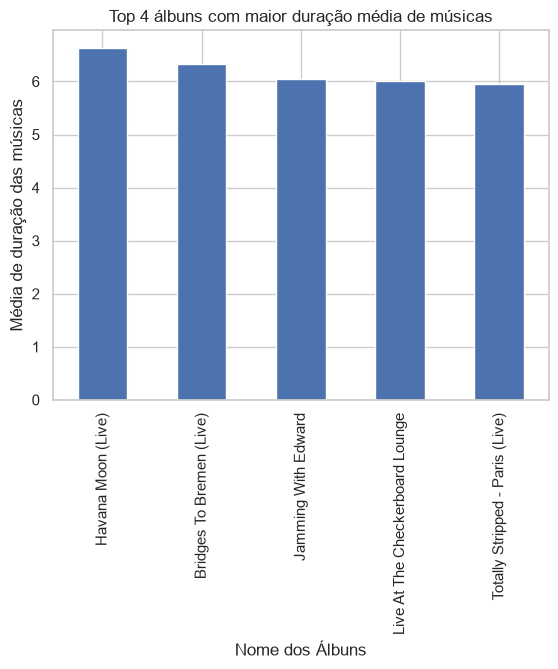

In [78]:
df_maior_duracao_musica.head(5).plot(kind="bar")
plt.xlabel("Nome dos Álbuns")
plt.ylabel("Média de duração das músicas")
plt.title("Top 4 álbuns com maior duração média de músicas")
plt.show()

### Insight — Duração média por álbum

A análise evidencia diferenças relevantes na duração média das faixas entre os álbuns.

Os maiores valores aparecem principalmente em lançamentos ao vivo, com destaque para **Havana Moon (Live)**, cuja duração média das faixas é de aproximadamente **6,63 minutos**, seguido por **Bridges To Bremen (Live)**, com aproximadamente **6,33 minutos**.

Em contraste, alguns álbuns apresentam médias próximas de **2,4 minutos**.

Esse comportamento sugere que o formato do lançamento pode estar associado à duração das faixas, especialmente quando são consideradas gravações ao vivo e performances mais extensas.


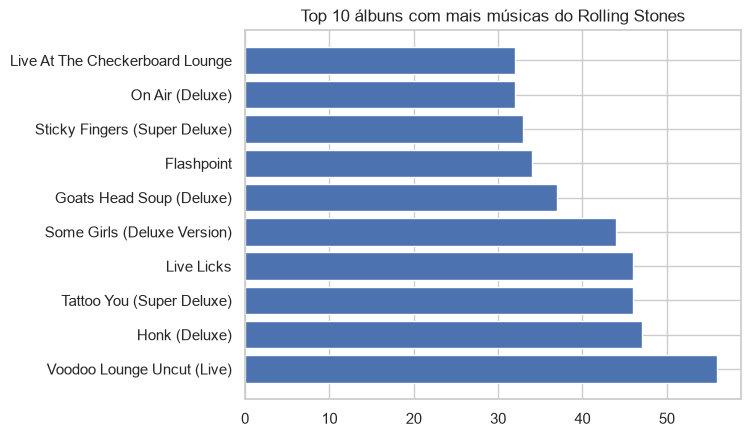

In [79]:
top_albums = df["album"].value_counts().head(10)
plt.barh(top_albums.index, top_albums.values)
plt.title("Top 10 álbuns com mais músicas do Rolling Stones")
plt.show()

### Insight — Quantidade de músicas por álbum

Os 10 álbuns com maior número de faixas concentram uma quantidade relevante de registros da base. Essa distribuição mostra que a quantidade de músicas não é uniforme entre os álbuns, existindo diferenças na extensão dos repertórios catalogados.

Esse tipo de análise também é importante para interpretar outras métricas por álbum, pois álbuns com maior número de faixas podem ter maior representação na base.


In [80]:
df_ultima_decada = df[df["release_date"].between(pd.to_datetime("2011"), pd.to_datetime("2020"))]


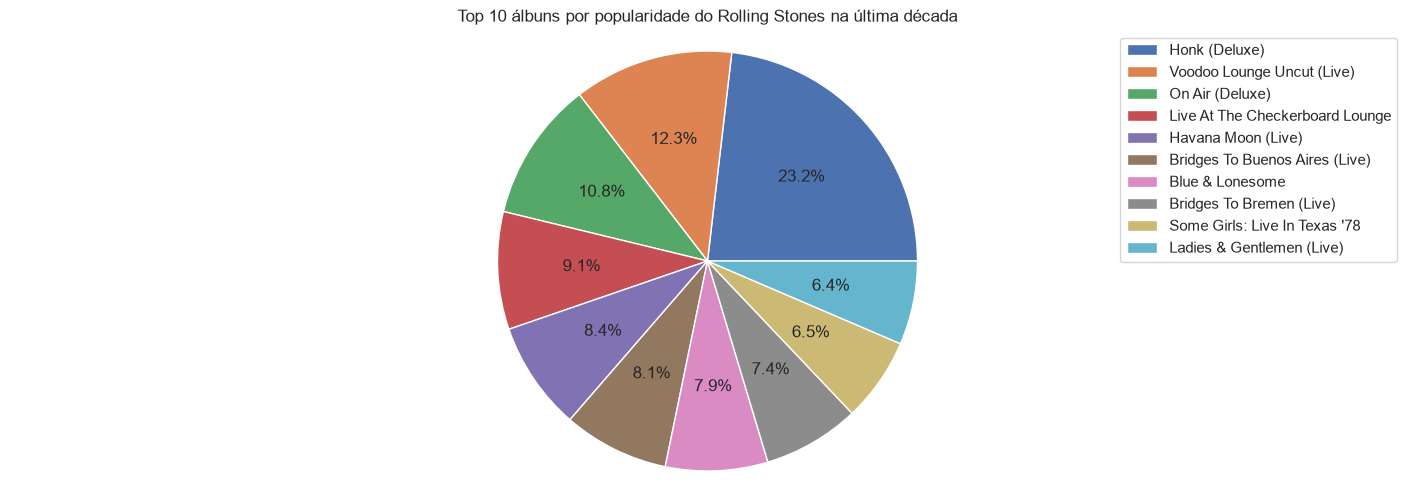

In [81]:
df_por_album = df_ultima_decada.groupby("album")["popularity"].sum().sort_values(ascending=False).head(10)

total_popularidade = df_por_album.sum()

df_porcentagem = df_por_album / total_popularidade * 100

labels = df_porcentagem.index.tolist()
sizes = df_porcentagem.values.tolist()

figura, grafico = plt.subplots(figsize=(18,6))
grafico.pie(sizes, autopct="%1.1f%%")
grafico.axis("equal")
plt.title("Top 10 álbuns por popularidade do Rolling Stones na última década")
plt.legend(labels, loc="best")
plt.show()

### Insight — Popularidade dos álbuns na última década

A análise da popularidade dos álbuns lançados ou disponibilizados na última década mostra que a popularidade está distribuída de forma diferente entre os 10 álbuns analisados.

Alguns álbuns concentram uma parcela maior da popularidade total, enquanto outros apresentam participação menor. O gráfico permite identificar quais lançamentos possuem maior participação relativa na soma de popularidade considerada na análise.

> **Observação:** a métrica representa a soma da popularidade das faixas de cada álbum e, portanto, também pode ser influenciada pela quantidade de músicas presente em cada álbum.


In [82]:
import seaborn as sns

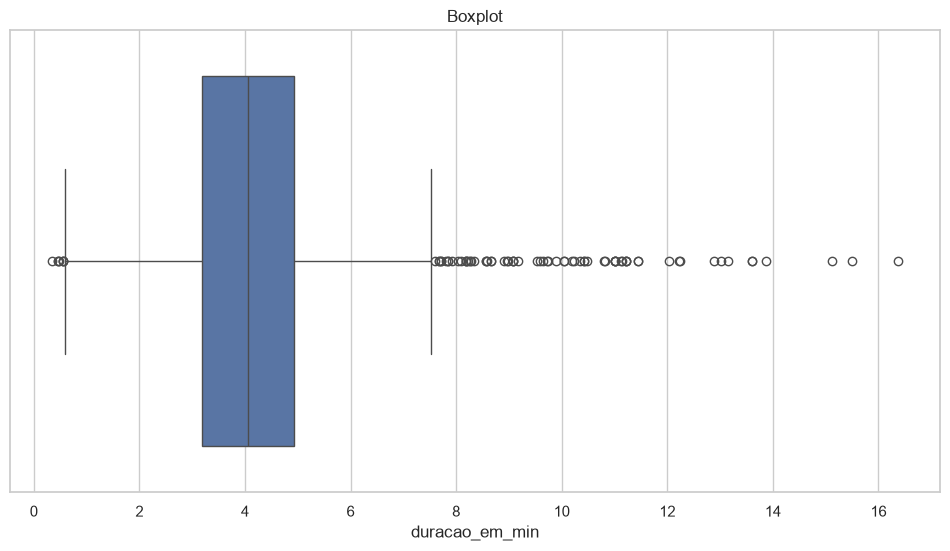

In [83]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(figsize=(12,6))
sns.boxplot(x="duracao_em_min", data=df)
axes.set_title("Boxplot")
plt.show()


### Insight — Distribuição da duração das músicas

O boxplot permite observar a distribuição da duração das músicas, destacando a mediana, a dispersão dos valores e possíveis valores extremos.

A visualização mostra que as durações não estão concentradas em um único valor, existindo músicas significativamente mais curtas e mais longas dentro da base. Os valores extremos também ajudam a identificar faixas que apresentam duração fora do comportamento mais comum.

Essa análise é complementada pelo gráfico de violino, que permite visualizar melhor a distribuição dos valores.


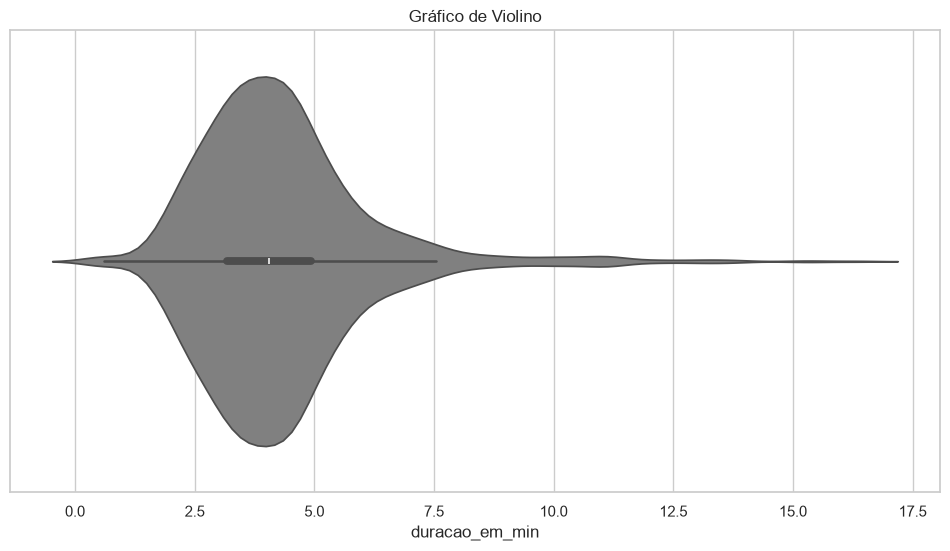

In [84]:
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="duracao_em_min", data=df, color="gray")
axes.set_title("Gráfico de Violino")
plt.show()

### Insight — Distribuição da duração

O gráfico de violino permite visualizar a concentração das durações das músicas ao longo da distribuição.

A maior concentração dos valores ocorre em torno das durações mais comuns da base, enquanto as extremidades representam músicas com durações menos frequentes. A visualização também evidencia a dispersão existente entre as faixas.


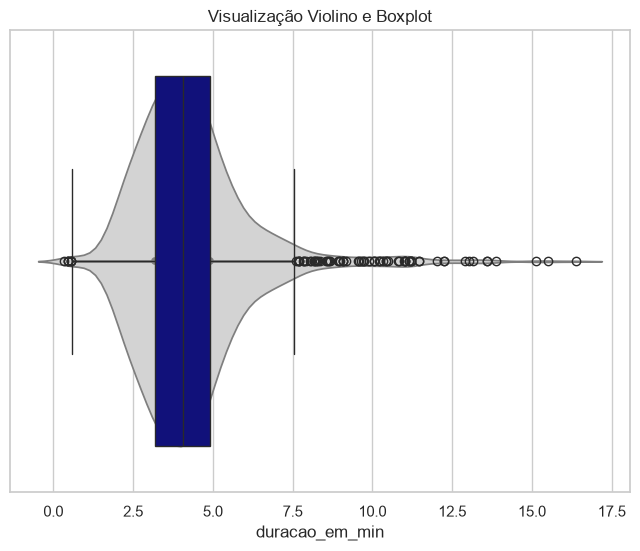

In [85]:
fig, ax = plt.subplots(figsize=(8,6))

sns.violinplot(x="duracao_em_min", data=df, ax=ax, color="lightgray")
sns.boxplot(x="duracao_em_min", data=df, ax=ax, whis=1.5, color="darkblue")
ax.set_title("Visualização Violino e Boxplot")
plt.show()

In [86]:
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100


In [87]:
def classifica_musica_ao_vivo(df): 
    if df["liveness"] >= 0.8:
        return True
    else:
        return False    

In [88]:
df["ao_vivo"] = df.apply(classifica_musica_ao_vivo, axis=1)

In [89]:
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000,True
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100,True


In [90]:
df.groupby("ao_vivo")["ao_vivo"].count()

ao_vivo
False    1112
True      498
Name: ao_vivo, dtype: int64

### Insight — Identificação de gravações ao vivo

Utilizando `liveness >= 0.8` como critério para classificar uma faixa como gravação ao vivo, foram identificadas **498 músicas classificadas como ao vivo** e **1.112 como músicas gravadas em estúdio**.

Isso representa aproximadamente **31% das observações classificadas como ao vivo** e **69% como gravadas em estúdio**.

A criação dessa variável permite comparar características musicais entre os dois grupos e investigar se o contexto de apresentação está associado a diferenças em duração, energia, valência ou outras características da música.


In [91]:
df_gravado_em_estudio = df[df["ao_vivo"] == False]
df_show_ao_vivo = df[df["ao_vivo"] == True]

In [92]:
df_gravado_em_estudio.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,0.2750,0.340,0.956,0.12500,0.741,-5539.0,0.0915,101628.0,0.125,31,244293,4.071550,False
23,Honky Tonk Women - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,1,0.1620,0.430,0.901,0.01100,0.694,-6215.0,0.0450,112077.0,0.890,32,216546,3.609100,False
25,Hand Of Fate - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,3,0.0654,0.477,0.899,0.03760,0.727,-6189.0,0.0425,129991.0,0.805,29,267866,4.464433,False
26,Route 66 - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,4,0.0975,0.473,0.923,0.00157,0.722,-6204.0,0.0791,144625.0,0.792,30,193653,3.227550,False
28,Crazy Mama - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,6,0.0288,0.447,0.883,0.00554,0.726,-6266.0,0.0371,117604.0,0.556,29,299213,4.986883,False


In [93]:
print("Média das músicas ao vivo: ", df_show_ao_vivo["duracao_em_min"].mean())

Média das músicas ao vivo:  5.088648962516734


In [94]:
print("Média das músicas em estúdio: ", df_gravado_em_estudio["duracao_em_min"].mean())

Média das músicas em estúdio:  3.940451363908873


### Insight — Duração: ao vivo × estúdio

A comparação mostra uma diferença na duração média das faixas entre os dois grupos.

As músicas classificadas como **ao vivo apresentam duração média de aproximadamente 5,09 minutos**, enquanto as músicas classificadas como **não ao vivo apresentam média de aproximadamente 3,94 minutos**.

A diferença é de aproximadamente **1,15 minuto por faixa**, indicando que as gravações classificadas como ao vivo tendem a apresentar maior duração média dentro desta base.

Essa diferença pode estar relacionada ao próprio formato das performances ao vivo, que pode incluir introduções, improvisações, solos ou extensões das músicas.

> **Observação:** essa análise descreve uma diferença observada na base e não permite, isoladamente, afirmar uma relação causal.


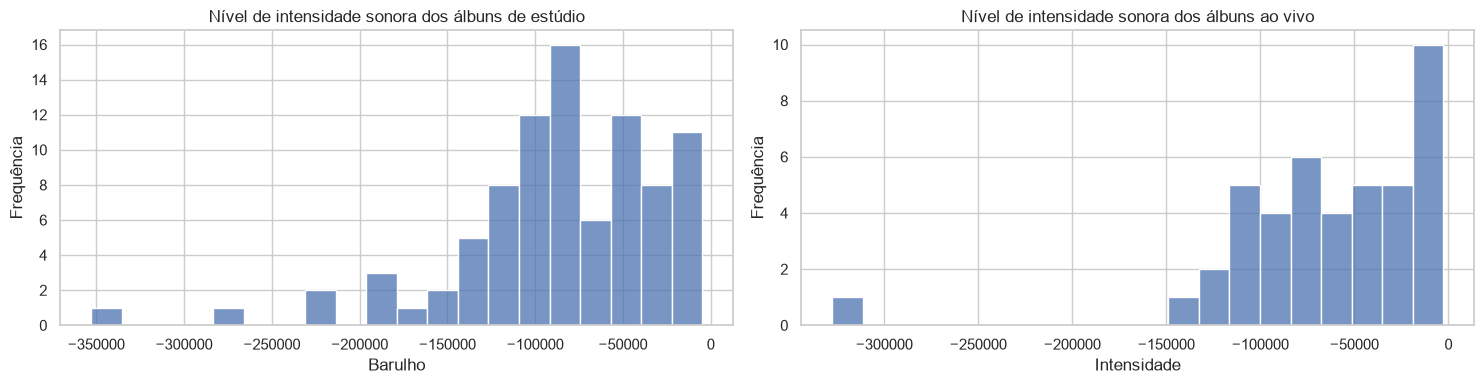

In [95]:
df_estudio = df_gravado_em_estudio.groupby("album")["loudness"].sum()
df_ao_vivo = df_show_ao_vivo.groupby("album")["loudness"].sum()

fig, axes = plt.subplots(1,2, figsize=(15,4))

sns.histplot(data=df_estudio, bins=20, ax=axes[0])
axes[0].set_title("Nível de intensidade sonora dos álbuns de estúdio")
axes[0].set_xlabel("Barulho")
axes[0].set_ylabel("Frequência")


sns.histplot(data=df_ao_vivo, bins=20, ax=axes[1])
axes[1].set_title("Nível de intensidade sonora dos álbuns ao vivo")
axes[1].set_xlabel("Intensidade")
axes[1].set_ylabel("Frequência")

fig.tight_layout()
plt.show()

### Insight — Intensidade sonora: estúdio × ao vivo

A distribuição da intensidade sonora apresenta comportamentos diferentes entre os álbuns classificados como gravações de estúdio e aqueles classificados como ao vivo.

A comparação das distribuições permite observar diferenças na concentração dos valores de `loudness` entre os dois grupos. Essa análise serve como ponto de partida para investigar, por meio de testes estatísticos, se a diferença observada entre as distribuições apresenta evidência estatística.


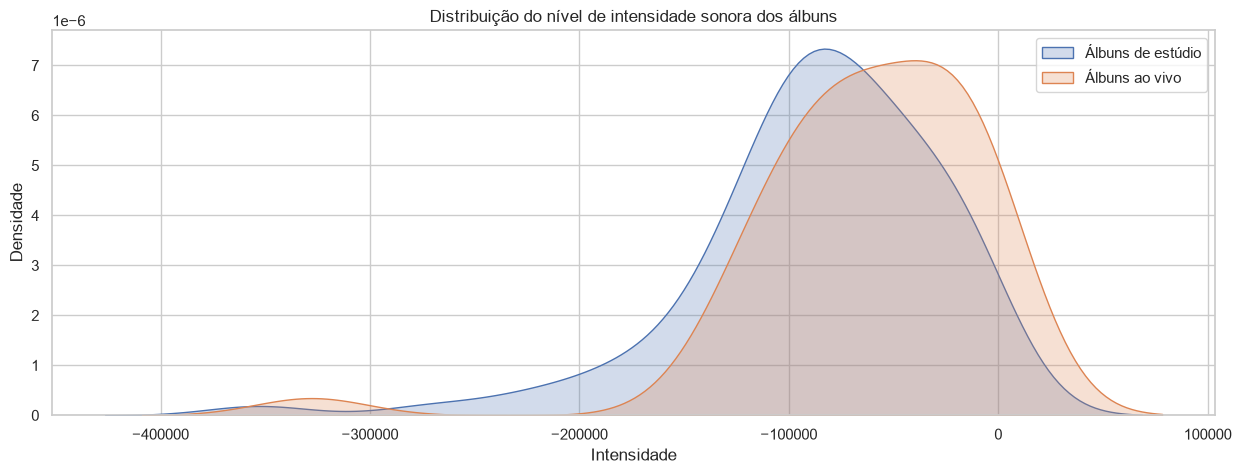

In [96]:
plt.figure(figsize=(15,5))

sns.kdeplot(data=df_estudio, label="Álbuns de estúdio", fill=True)
sns.kdeplot(data=df_ao_vivo, label="Álbuns ao vivo", fill=True)

plt.title("Distribuição do nível de intensidade sonora dos álbuns")
plt.xlabel("Intensidade")
plt.ylabel("Densidade")
plt.legend()


### Insight — Distribuição da intensidade sonora

A curva de densidade permite comparar a distribuição da intensidade sonora entre os álbuns de estúdio e os álbuns ao vivo.

As curvas mostram como os valores estão concentrados em cada grupo e permitem identificar diferenças no formato e na posição das distribuições. Essa visualização complementa os histogramas e ajuda a justificar a aplicação dos testes estatísticos realizados posteriormente.


### Teste de hipótese estatístico

In [97]:
from scipy.stats import shapiro

In [98]:
stat, p = shapiro(df_estudio)
print("Soma da intensidade dos álbuns de estúdio: ")
print("Estatística de teste: {:.4f}, valor p: {}".format(stat, p))

if p > 0.05:
    print("Não há evidência suficiente para rejeitar a hipótese de normalidade")
else:
    print("A hipótese de normalidade é rejeitada")


Soma da intensidade dos álbuns de estúdio: 
Estatística de teste: 0.8958, valor p: 3.2961810670595794e-06
A hipótese de normalidade é rejeitada


In [99]:
stat, p = shapiro(df_ao_vivo)
print("Soma da intensidade dos álbuns ao vivo: ")
print("Estatística de teste: {:.4f}, valor p: {}".format(stat, p))

if p > 0.05:
    print("Não há evidência suficiente para rejeitar a hipótese de normalidade")
else:
    print("A hipótese de normalidade é rejeitada")


Soma da intensidade dos álbuns ao vivo: 
Estatística de teste: 0.7913, valor p: 2.3506009205064346e-06
A hipótese de normalidade é rejeitada


### Insight — Teste de normalidade

O teste de Shapiro-Wilk foi utilizado para verificar se os dados apresentavam uma distribuição normal.

Nos dois grupos analisados, o valor de **p foi menor que 0,05**, indicando que os dados não apresentam distribuição normal.

Por isso, foi utilizado o **teste de Mann-Whitney** para comparar os grupos.


In [100]:
from scipy.stats import mannwhitneyu

In [101]:
stat, p = mannwhitneyu(df_estudio.sample(len(df_estudio)), df_ao_vivo.sample(len(df_ao_vivo)), alternative="less")
print("Estatística de teste U: ", stat)
print("Valor p: ", p)

alpha = 0.05
if p < alpha:
    print("Diferença estatisticamente significante")
else:
    print("Não há diferença estatisticamente significante")


Estatística de teste U:  1367.0
Valor p:  0.0050727361177996585
Diferença estatisticamente significante


### Insight — Teste estatístico

Foi aplicado o teste de **Mann-Whitney U** para comparar a intensidade sonora dos álbuns de estúdio e dos álbuns ao vivo.

O teste apresentou **U = 1367** e **p = 0,0051**. Como o valor de p é menor que **0,05**, há evidência estatística de diferença entre os dois grupos analisados.


In [102]:
media_por_album = df.groupby("album")["valence"].mean().reset_index()

media_por_album = media_por_album.rename(columns={"valence": "media_valence"})

media_por_album["sentimento"] = ["positivo" if v > 0.6 else "negativo" for v in media_por_album["media_valence"]]

media_por_album.groupby("sentimento")["sentimento"].count()

sentimento
negativo    38
positivo    52
Name: sentimento, dtype: int64

### Insight — Valência dos álbuns

A partir da média de `valence` de cada álbum, foi estabelecido o critério de classificação em **positivo**, para valores superiores a 0.6, e **negativo**, para valores iguais ou inferiores a 0.6.

Com esse critério, foram classificados **52 álbuns como positivos** e **38 como negativos**.

Portanto, dentro do critério definido nesta análise, existe uma maior quantidade de álbuns classificados como positivos. Essa classificação representa uma regra criada para a análise e não uma avaliação subjetiva do conteúdo das músicas.


In [103]:
media_por_album.head()

,album,media_valence,sentimento
0,12 X 5,0.704000,positivo
1,12 x 5,0.689917,positivo
2,A Bigger Bang (2009 Re-Mastered),0.602750,positivo
3,A Bigger Bang (Live),0.253482,negativo
4,Aftermath,0.684818,positivo


In [104]:
df_resultado_final = pd.merge(df, media_por_album, on = "album") #Faço um merge comparando a média por álbum com todo o dataset pela coluna álbum
df_resultado_final.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo,media_valence,sentimento
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True,0.27117,negativo
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True,0.27117,negativo
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True,0.27117,negativo
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000,True,0.27117,negativo
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100,True,0.27117,negativo


In [105]:
matriz_correlacao = df_resultado_final.corr(numeric_only=True)

correlacao_sentimento = matriz_correlacao["media_valence"]

display(correlacao_sentimento)

track_number       -0.115007
acousticness        0.015491
danceability        0.492945
energy             -0.347447
instrumentalness    0.133741
liveness           -0.571749
loudness           -0.229543
speechiness        -0.416005
tempo              -0.028887
valence             0.603258
popularity          0.100509
duration_ms        -0.309499
duracao_em_min     -0.309499
ao_vivo            -0.549736
media_valence       1.000000
Name: media_valence, dtype: float64

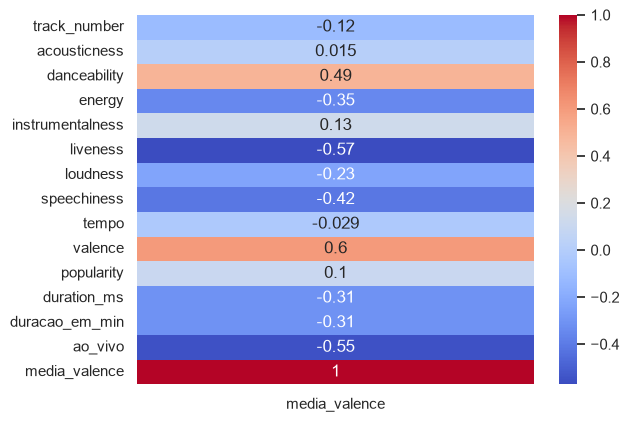

In [106]:
sns.heatmap(correlacao_sentimento.to_frame(), annot=True, cmap="coolwarm")

plt.show()

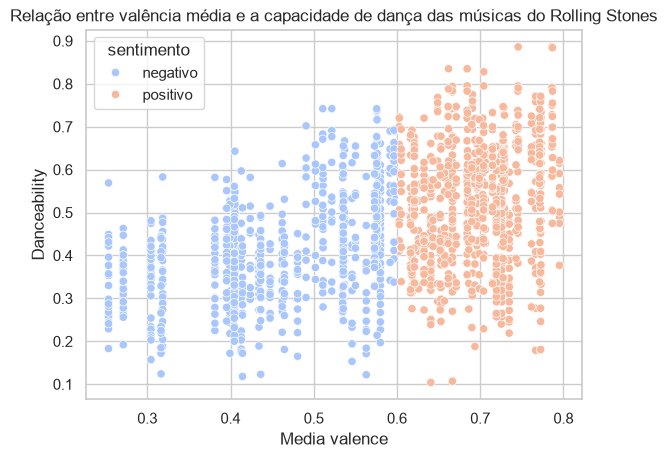

In [107]:
sns.scatterplot(x="media_valence", y="danceability", hue="sentimento", data=df_resultado_final, palette="coolwarm")
plt.xlabel("Media valence")
plt.ylabel("Danceability")
plt.title("Relação entre valência média e a capacidade de dança das músicas do Rolling Stones")
plt.show()

### Insight — Valência × dançabilidade

O gráfico de dispersão permite investigar a relação entre a **valência média dos álbuns** e a **dançabilidade das músicas**.

A distribuição dos pontos permite observar se existe uma tendência de aumento ou redução da dançabilidade conforme a valência média do álbum varia. A separação por sentimento também facilita a visualização dos grupos definidos anteriormente.

A análise deve ser interpretada em conjunto com o coeficiente de correlação, evitando concluir uma relação apenas pela distribuição visual dos pontos.


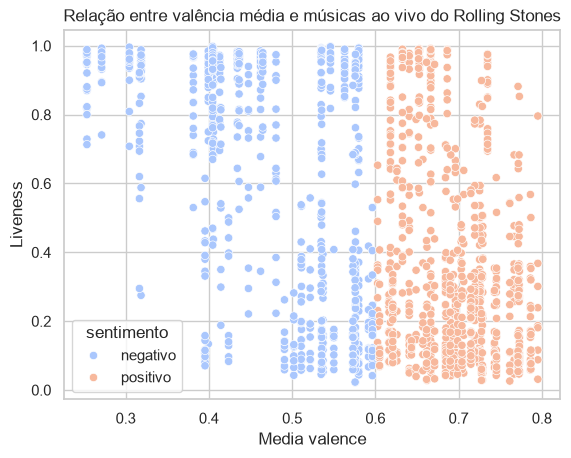

In [108]:
sns.scatterplot(x="media_valence", y="liveness", hue="sentimento", data=df_resultado_final, palette="coolwarm")

plt.xlabel("Media valence")
plt.ylabel("Liveness")
plt.title("Relação entre valência média e músicas ao vivo do Rolling Stones")
plt.show()

### Insight — Valência × liveness

O gráfico de dispersão permite analisar a relação entre a **valência média dos álbuns** e o indicador `liveness`, utilizado na análise para identificar características associadas a gravações ao vivo.

A distribuição dos pontos permite verificar visualmente se existe alguma tendência entre essas variáveis e como os álbuns classificados como positivos e negativos estão distribuídos.

Assim como na análise anterior, a existência de uma associação deve ser avaliada em conjunto com a correlação calculada, e não apenas pela observação visual do gráfico.


# Principais Insights

Ao longo da análise exploratória, foram identificados os seguintes pontos:

### 1. Qualidade da base

A base possui **1.610 registros e 15 variáveis**, sem valores ausentes. Foram identificados **6 registros duplicados**, que devem ser considerados no processo de preparação dos dados.

### 2. Perfil musical

As características analisadas apresentam ampla variação entre as faixas, permitindo explorar diferentes perfis musicais dentro da discografia dos Rolling Stones.

### 3. Duração das músicas

A duração média das faixas é de aproximadamente **4,30 minutos**, com diferenças relevantes entre os álbuns analisados.

### 4. Álbuns ao vivo

Os álbuns com maiores durações médias incluem principalmente lançamentos ao vivo, com destaque para **Havana Moon (Live)** e **Bridges To Bremen (Live)**.

### 5. Gravações ao vivo

Utilizando `liveness >= 0.8` como critério de classificação, **498 registros foram classificados como ao vivo**, enquanto **1.112 foram classificados como não ao vivo**.

### 6. Duração — ao vivo × não ao vivo

As faixas classificadas como ao vivo apresentaram duração média de aproximadamente **5,09 minutos**, contra **3,94 minutos** para as classificadas como não ao vivo.

### 7. Análise estatística

Os testes estatísticos foram utilizados para avaliar se diferenças observadas na exploração dos dados apresentam evidência estatística, complementando a análise visual e descritiva.

---

## Conclusão

A análise demonstra como técnicas de **Python, estatística descritiva, visualização e testes de hipóteses** podem ser utilizadas para explorar uma base de dados musical e transformar registros individuais em informações interpretáveis.

O projeto também evidencia a importância de combinar **qualidade dos dados + exploração + visualização + estatística**, evitando tirar conclusões apenas a partir de diferenças visuais ou valores médios.
